In [ ]:
# ==============================================================================
# CELL 1: INSTALL DEPENDENCIES
# ==============================================================================
!pip install kagglehub tensorflow scikit-learn pandas matplotlib seaborn


In [ ]:
# ==============================================================================
# CELL 2: SETUP, IMPORTS, AND MOUNT DRIVE
# ==============================================================================
import os
import shutil
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, applications, callbacks
from sklearn.metrics import confusion_matrix, classification_report
import kagglehub
from tensorflow.keras.preprocessing import image_dataset_from_directory

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# Mount Google Drive to save our final model and classes
try:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_model_dir = '/content/drive/MyDrive/Mushroom_Classification_Project'
except ImportError:
    print("Not running in Colab. Will save locally.")
    drive_model_dir = './Mushroom_Classification_Project'

os.makedirs(drive_model_dir, exist_ok=True)
print(f"Models and PKL file will be saved to: {drive_model_dir}")


Num GPUs Available:  1
Mounted at /content/drive
Models and PKL file will be saved to: /content/drive/MyDrive/Mushroom_Classification_Project


In [ ]:
# ==============================================================================
# CELL 3: DOWNLOAD DATASET & CLEAN CORRUPTED IMAGES
# ==============================================================================
print("Downloading dynamic Mushroom dataset...")
path = kagglehub.dataset_download("maysee/mushrooms-classification-common-genuss-images")

# The cache is read-only. We need to copy it to a writable directory so we can delete bad JPEGs!
readonly_dataset_dir = path
if 'Mushrooms' in os.listdir(path):
    readonly_dataset_dir = os.path.join(path, 'Mushrooms')

dataset_dir = '/tmp/writable_mushrooms_dataset'

if os.path.exists(dataset_dir):
    shutil.rmtree(dataset_dir)

print(f"Copying files to {dataset_dir} for cleaning...")
shutil.copytree(readonly_dataset_dir, dataset_dir)

print("Cleaning writable dataset: Searching for corrupted images...")
num_skipped = 0
for folder_name in os.listdir(dataset_dir):
    folder_path = os.path.join(dataset_dir, folder_name)
    if os.path.isdir(folder_path):
        for fname in os.listdir(folder_path):
            fpath = os.path.join(folder_path, fname)
            try:
                # Try reading and decoding the image to catch corrupt files
                image_string = tf.io.read_file(fpath)
                _ = tf.io.decode_image(image_string, expand_animations=False)
            except Exception as e:
                os.remove(fpath) # Unreadable JPEG; delete it
                num_skipped += 1

print(f"✅ Successfully deleted {num_skipped} corrupted images!")


100%|██████████| 1.85G/1.85G [01:58<00:00, 16.8MB/s]

Extracting files...


Copying files to /tmp/writable_mushrooms_dataset for cleaning...
Cleaning writable dataset: Searching for corrupted images...
✅ Successfully deleted 1 corrupted images!


In [ ]:
# ==============================================================================
# CELL 4: PREPARE TRAINING & VALIDATION DATASETS
# ==============================================================================
batch_size = 32
img_height = 224
img_width = 224

# Create training set using our cleaned writable directory
train_ds = image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Create validation set
val_ds = image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Extract and save class names as a .pkl file for the frontend
class_names = train_ds.class_names
print("Class names found:", class_names)

pkl_path = os.path.join(drive_model_dir, "classes.pkl")
with open(pkl_path, 'wb') as f:
    pickle.dump(class_names, f)
print(f"Class names successfully saved to {pkl_path}")


Found 6713 files belonging to 9 classes.
Using 5371 files for training.
Found 6713 files belonging to 9 classes.
Using 1342 files for validation.
Class names found: ['Agaricus', 'Amanita', 'Boletus', 'Cortinarius', 'Entoloma', 'Hygrocybe', 'Lactarius', 'Russula', 'Suillus']
Class names successfully saved to /content/drive/MyDrive/Mushroom_Classification_Project/classes.pkl


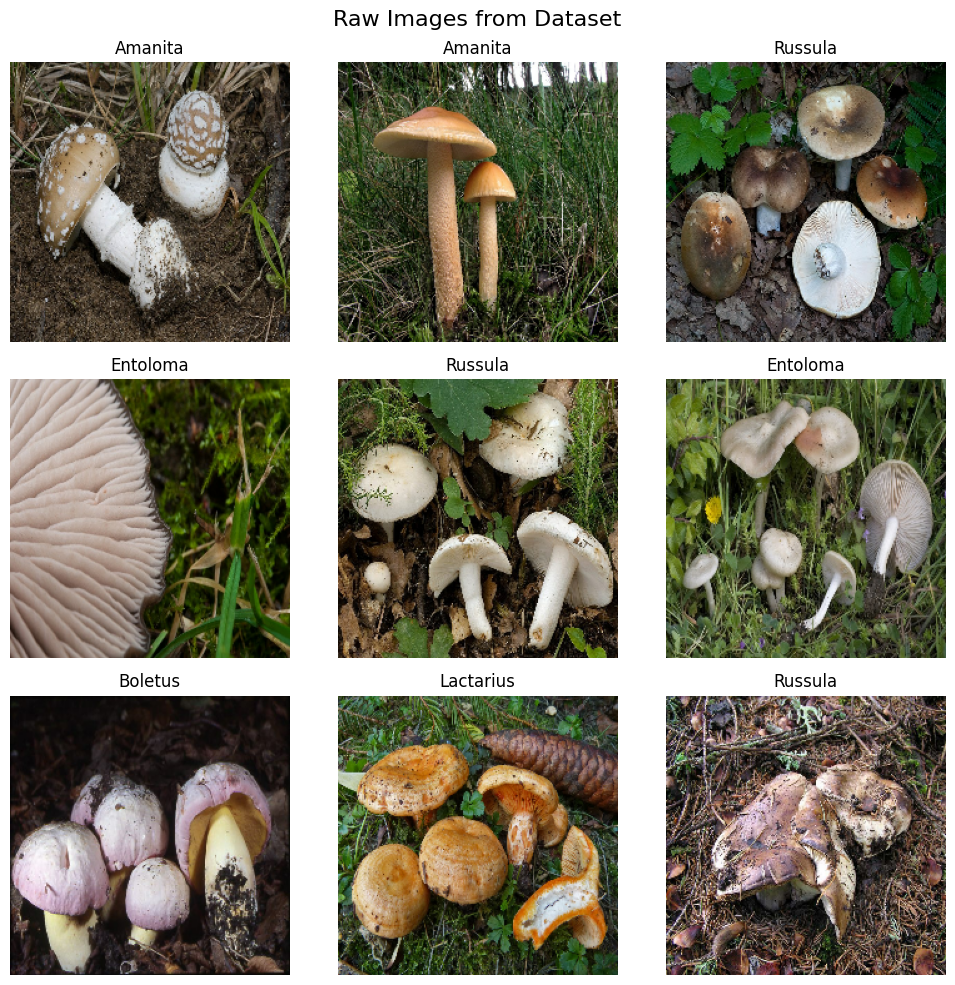

In [ ]:
# ==============================================================================
# CELL 5: VISUAL EDA - SHOW ROW IMAGES
# ==============================================================================
plt.figure(figsize=(10, 10))
plt.suptitle("Raw Images from Dataset", fontsize=16)

# Take one batch from the training dataset
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Images are loaded as float32/uint8.
        img = images[i].numpy().astype("uint8")
        plt.imshow(img)
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()


Counting class distributions... (this may take a few seconds)


/tmp/ipykernel_6485/710691097.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')


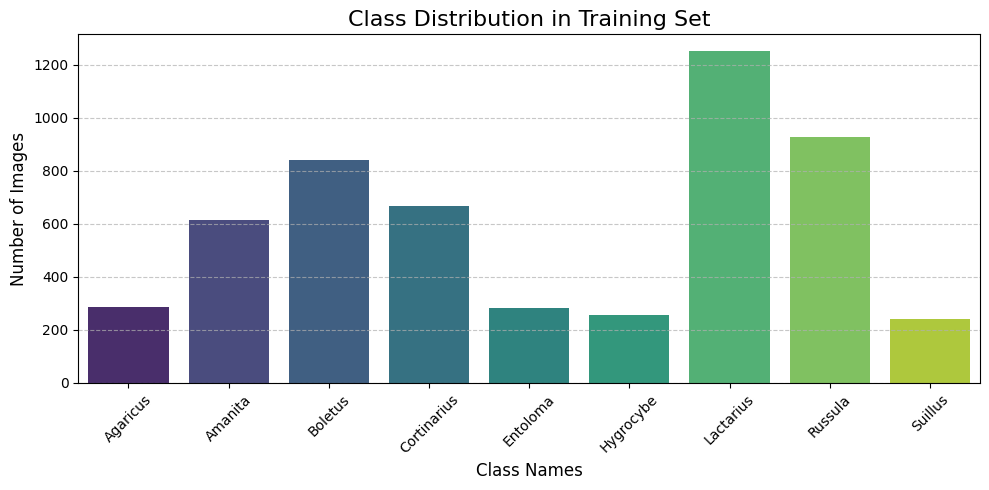

Class Counts: {'Agaricus': 287, 'Amanita': 616, 'Boletus': 840, 'Cortinarius': 669, 'Entoloma': 283, 'Hygrocybe': 255, 'Lactarius': 1253, 'Russula': 928, 'Suillus': 240}


In [ ]:
# ==============================================================================
# CELL 6: VISUAL EDA - CLASS DISTRIBUTION
# ==============================================================================
# Iterate through the dataset to count the occurrences of each class
class_counts = {class_name: 0 for class_name in class_names}

print("Counting class distributions... (this may take a few seconds)")
for images, labels in train_ds.unbatch():
    class_counts[class_names[labels.numpy()]] += 1

# Plotting the Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette='viridis')
plt.title('Class Distribution in Training Set', fontsize=16)
plt.xlabel('Class Names', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Class Counts:", class_counts)


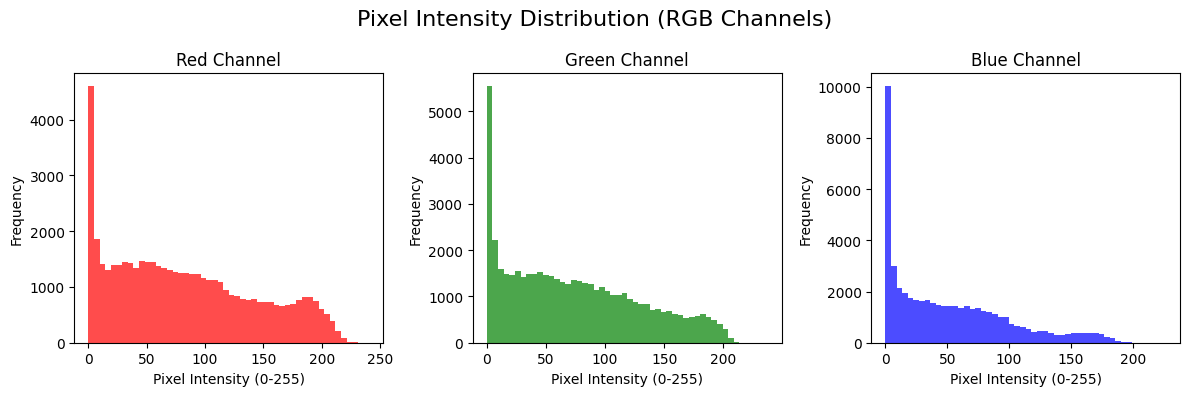

In [ ]:
# ==============================================================================
# CELL 7: VISUAL EDA - PIXEL INTENSITY HISTOGRAM
# ==============================================================================
plt.figure(figsize=(12, 4))
plt.suptitle("Pixel Intensity Distribution (RGB Channels)", fontsize=16)

# Grab a single image for histogram analysis
for images, labels in train_ds.take(1):
    sample_img = images[0].numpy()
    break

colors = ('r', 'g', 'b')
channels = ('Red', 'Green', 'Blue')

for i, color in enumerate(colors):
    plt.subplot(1, 3, i+1)
    # Flatten the 2D channel array to 1D to plot the histogram
    channel_data = sample_img[:, :, i].ravel()
    plt.hist(channel_data, bins=50, color=color, alpha=0.7)
    plt.title(f'{channels[i]} Channel')
    plt.xlabel('Pixel Intensity (0-255)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


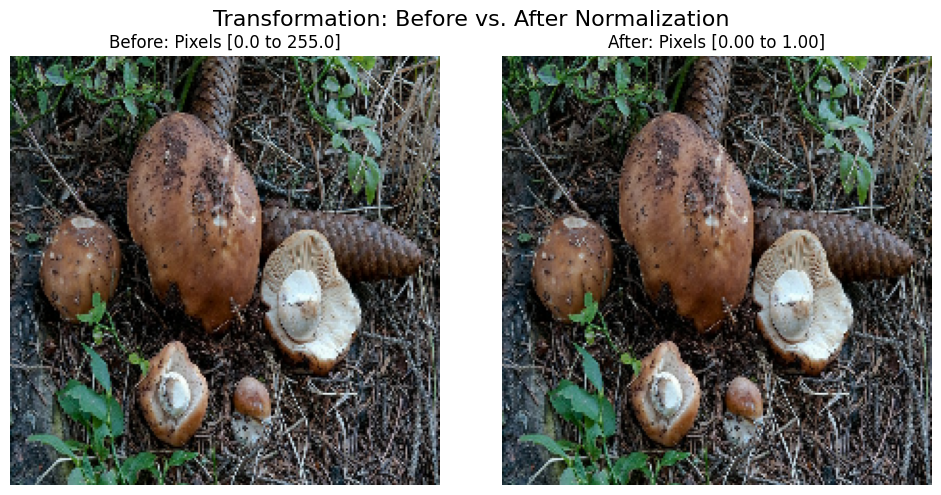

In [ ]:
# ==============================================================================
# CELL 8: PREPROCESSING - RESIZING & SCALING (BEFORE VS AFTER)
# ==============================================================================
# Definition of the normalization layer
normalization_layer = layers.Rescaling(1./255)

# Demonstrate the transformation on a single image
plt.figure(figsize=(10, 5))
plt.suptitle("Transformation: Before vs. After Normalization", fontsize=16)

for images, labels in train_ds.take(1):
    raw_img = images[0]
    scaled_img = normalization_layer(raw_img)

    # 1. Before Normalization
    plt.subplot(1, 2, 1)
    plt.imshow(raw_img.numpy().astype("uint8"))
    plt.title(f"Before: Pixels [{np.min(raw_img)} to {np.max(raw_img)}]")
    plt.axis('off')

    # 2. After Normalization
    plt.subplot(1, 2, 2)
    plt.imshow(scaled_img.numpy()) # imshow handles floats in [0, 1] automatically
    plt.title(f"After: Pixels [{np.min(scaled_img):.2f} to {np.max(scaled_img):.2f}]")
    plt.axis('off')
    break

plt.tight_layout()
plt.show()

# Apply system optimization to memory to increase dataset training speed
AUTOTUNE = tf.data.AUTOTUNE
train_ds_opt = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds_opt = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [ ]:
# ==============================================================================
# CELL 9: MODEL 1 - THE BASELINE (SIMPLE CNN)
# ==============================================================================
print("--- Building Model 1: Baseline CNN ---")
num_classes = len(class_names)
input_shape = (img_height, img_width, 3)

model_1 = models.Sequential([
    layers.InputLayer(input_shape=input_shape),
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
], name="Baseline_CNN")

model_1.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

print(model_1.summary())

# Train Model 1
history_1 = model_1.fit(train_ds_opt, validation_data=val_ds_opt, epochs=10)


--- Building Model 1: Baseline CNN ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    25,690,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,710,793 (98.08 MB)

 Trainable params: 25,710,793 (98.08 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 44s 106ms/step - accuracy: 0.2506 - loss: 2.2553 - val_accuracy: 0.3323 - val_loss: 1.9512
Epoch 2/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 47s 44ms/step - accuracy: 0.4048 - loss: 1.7043 - val_accuracy: 0.3554 - val_loss: 1.8426
Epoch 3/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.6044 - loss: 1.1575 - val_accuracy: 0.3592 - val_loss: 1.9267
Epoch 4/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.8557 - loss: 0.4650 - val_accuracy: 0.3338 - val_loss: 2.6125
Epoch 5/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.9697 - loss: 0.1204 - val_accuracy: 0.3346 - val_loss: 3.6866
Epoch 6/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.9896 - loss: 0.0480 - val_accuracy: 0.3323 - val_loss: 4.0993
Epoch 7/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.9937 - loss: 0.0248 - val_accuracy: 0.3152 - val_loss: 4.5692
Epoch 8/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.9939 - loss: 0.0238 - 

In [ ]:
# ==============================================================================
# CELL 10: MODEL 2 - REFINED MODEL (PRE-TRAINED MOBILENETV2)
# ==============================================================================
print("--- Building Model 2: Refined Transfer Learning ---")

# Load pre-trained MobileNetV2 without the Dense top layer
base_model_2 = applications.MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
base_model_2.trainable = False # Freeze the base model to prevent destroying pre-trained weights

model_2 = models.Sequential([
    layers.InputLayer(input_shape=input_shape),
    layers.Rescaling(1./255),
    base_model_2,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2), # Dropout added manually to offset basic overfitting
    layers.Dense(num_classes, activation='softmax')
], name="Refined_Transfer_Learning")

model_2.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# Train Model 2
history_2 = model_2.fit(train_ds_opt, validation_data=val_ds_opt, epochs=10)


--- Building Model 2: Refined Transfer Learning ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 55s 209ms/step - accuracy: 0.5679 - loss: 1.2445 - val_accuracy: 0.6878 - val_loss: 0.9077
Epoch 2/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.7068 - loss: 0.8169 - val_accuracy: 0.7004 - val_loss: 0.8325
Epoch 3/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.7678 - loss: 0.6595 - val_accuracy: 0.7459 - val_loss: 0.7492
Epoch 4/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.8051 - loss: 0.5484 - val_accuracy: 0.7377 - val_loss: 0.7338
Epoch 5/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.8406 - loss: 0.4532 - val_accuracy: 0.7511 - val_loss: 0.7775
Epoch 6/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8693 - loss: 0.3890 - val_accuracy: 0.7638 - val_loss: 0.7147
Epoch 7/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.8898 - loss: 0.3264 - val_accuracy: 0.7720 - val_loss: 0

In [ ]:
# ==============================================================================
# CELL 11: MODEL 3 - OPTIMIZED CHAMPION
# ==============================================================================
print("--- Building Model 3: The Optimized Champion ---")

# Data Augmentation Layer block prevents pattern memorization
data_augmentation = models.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
], name="Data_Augmentation")

base_model_3 = applications.MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
base_model_3.trainable = True # Fine-tuning: make base model trainable

# Freeze all layers EXCEPT the top 20 layers for heavy fine-tuning
for layer in base_model_3.layers[:-20]:
    layer.trainable = False

model_3 = models.Sequential([
    layers.InputLayer(input_shape=input_shape),
    data_augmentation,
    layers.Rescaling(1./255),
    base_model_3,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
], name="Optimized_Champion")

# Use a lower learning rate than default (1e-4) to safely learn precise weights
opt = tf.keras.optimizers.Adam(learning_rate=0.0001)

# Learning Rate Scheduler to adjust learning rate dynamically if validation loss spikes
lr_scheduler = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

model_3.compile(optimizer=opt,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# Train Model 3
history_3 = model_3.fit(train_ds_opt, validation_data=val_ds_opt, epochs=10, callbacks=[lr_scheduler])

# Optional Step: Save the very best model we made to our drive
best_model_path = os.path.join(drive_model_dir, "mushroom_champion_classifier.h5")
model_3.save(best_model_path)
print(f"Optimal Champion Model Exported to > {best_model_path}")


--- Building Model 3: The Optimized Champion ---
Epoch 1/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 28s 96ms/step - accuracy: 0.4885 - loss: 1.4728 - val_accuracy: 0.5604 - val_loss: 1.3844 - learning_rate: 1.0000e-04
Epoch 2/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step - accuracy: 0.6537 - loss: 1.0032 - val_accuracy: 0.5894 - val_loss: 1.6153 - learning_rate: 1.0000e-04
Epoch 3/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7007 - loss: 0.8350
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
168/168 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step - accuracy: 0.7094 - loss: 0.8181 - val_accuracy: 0.6334 - val_loss: 1.4379 - learning_rate: 1.0000e-04
Epoch 4/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 14s 81ms/step - accuracy: 0.7682 - loss: 0.6830 - val_accuracy: 0.6826 - val_loss: 1.0926 - learning_rate: 5.0000e-05
Epoch 5/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.7784 - loss: 0.6368 - val_accuracy: 0.6669 - val_loss: 1.1730 - learning_rate: 5.0000e-05
Epoch 6/1

Optimal Champion Model Exported to > /content/drive/MyDrive/Mushroom_Classification_Project/mushroom_champion_classifier.h5


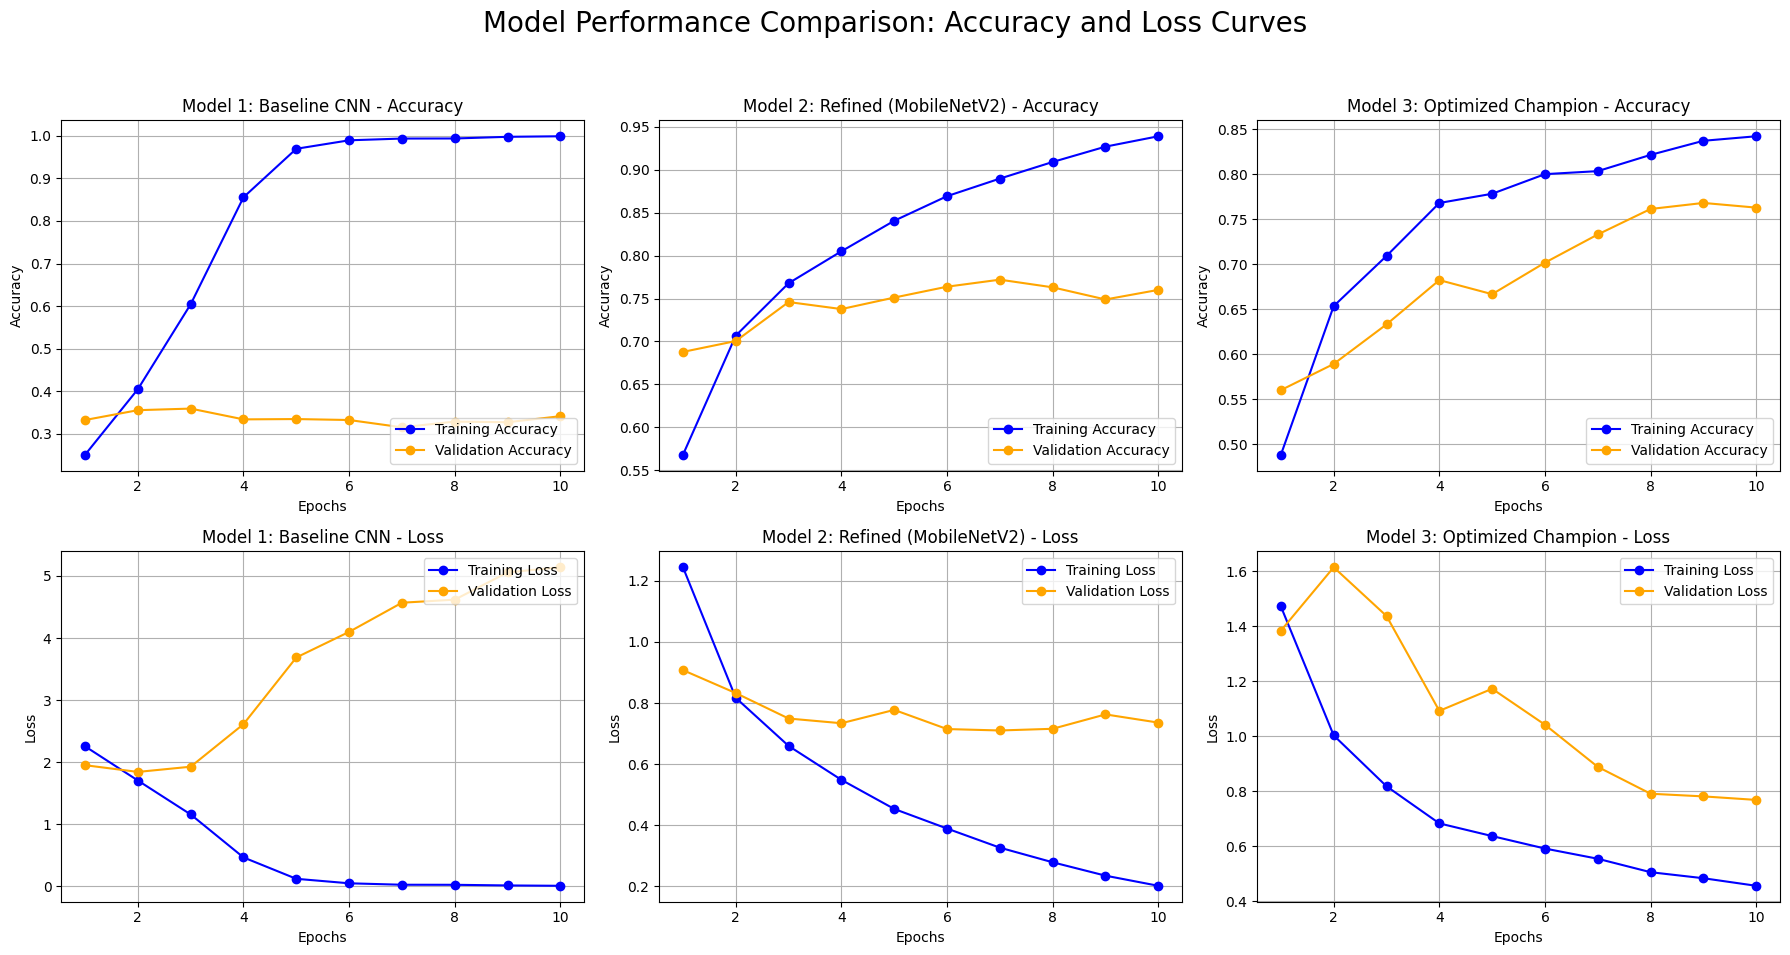

In [ ]:
# ==============================================================================
# CELL 12: VISUAL COMPARISON CURVES
# ==============================================================================
histories = [history_1, history_2, history_3]
titles = ['Model 1: Baseline CNN', 'Model 2: Refined (MobileNetV2)', 'Model 3: Optimized Champion']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Model Performance Comparison: Accuracy and Loss Curves", fontsize=20)

for i, hist in enumerate(histories):
    acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    loss = hist.history['loss']
    val_loss = hist.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    # Plot Accuracy
    axes[0, i].plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
    axes[0, i].plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', marker='o')
    axes[0, i].set_title( titles[i] + ' - Accuracy')
    axes[0, i].set_xlabel('Epochs')
    axes[0, i].set_ylabel('Accuracy')
    axes[0, i].legend(loc='lower right')
    axes[0, i].grid(True)

    # Plot Loss
    axes[1, i].plot(epochs_range, loss, label='Training Loss', color='blue', marker='o')
    axes[1, i].plot(epochs_range, val_loss, label='Validation Loss', color='orange', marker='o')
    axes[1, i].set_title(titles[i] + ' - Loss')
    axes[1, i].set_xlabel('Epochs')
    axes[1, i].set_ylabel('Loss')
    axes[1, i].legend(loc='upper right')
    axes[1, i].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
# ==============================================================================
# CELL 13: COMPARISON TABLE
# ==============================================================================
comparison_data = {
    "Model Version": ["Model 1 (Baseline)", "Model 2 (Refined)", "Model 3 (Champion)"],
    "Architecture": ["Custom Basic CNN", "Transfer Learning (MobileNetV2 Frozen)", "Transfer Learning (MobileNetV2 Unfrozen + Augmentation)"],
    "Advantages": ["Quick to build, simple, easy to understand", "High accuracy rapidly, leverages pre-trained patterns", "Peak generalizability, robust against overfitting, highly accurate"],
    "Disadvantages": ["Prone to overfitting, struggles with complex traits", "Cannot learn new domain-specific deep features", "Slower to train, requires careful hyperparameter tuning"],
    "Enhancements Taken": ["None (Starting Floor)", "Replaced custom filters with ImageNet weights", "Added Random Flips/Rotations, Fine-tuned top 20 layers, LR Scheduler"]
}

df_comparison = pd.DataFrame(comparison_data)

# Display tabular data styled for Colab
display(df_comparison.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [dict(selector='th', props=[('text-align', 'left'), ('background-color', '#4CAF50'), ('color', 'white')])]
))


,Model Version,Architecture,Advantages,Disadvantages,Enhancements Taken
0,Model 1 (Baseline),Custom Basic CNN,"Quick to build, simple, easy to understand","Prone to overfitting, struggles with complex traits",None (Starting Floor)
1,Model 2 (Refined),Transfer Learning (MobileNetV2 Frozen),"High accuracy rapidly, leverages pre-trained patterns",Cannot learn new domain-specific deep features,Replaced custom filters with ImageNet weights
2,Model 3 (Champion),Transfer Learning (MobileNetV2 Unfrozen + Augmentation),"Peak generalizability, robust against overfitting, highly accurate","Slower to train, requires careful hyperparameter tuning","Added Random Flips/Rotations, Fine-tuned top 20 layers, LR Scheduler"


--- Generating Confusion Matrix for Champion Model ---


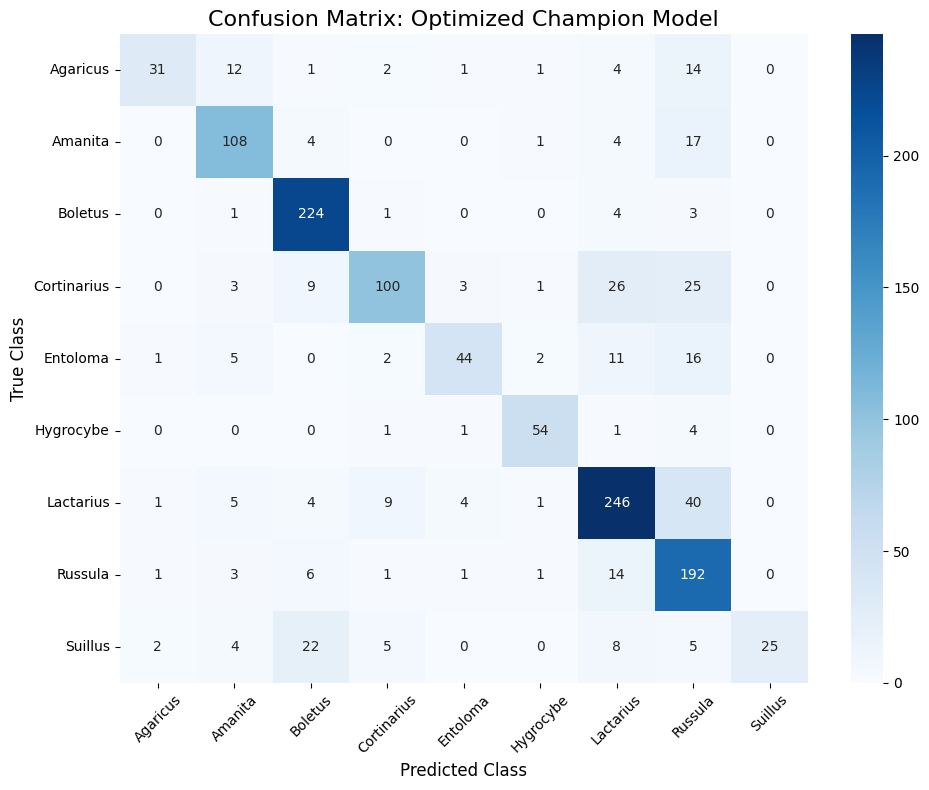


--- Classification Report ---
              precision    recall  f1-score   support

    Agaricus       0.86      0.47      0.61        66
     Amanita       0.77      0.81      0.79       134
     Boletus       0.83      0.96      0.89       233
 Cortinarius       0.83      0.60      0.69       167
    Entoloma       0.81      0.54      0.65        81
   Hygrocybe       0.89      0.89      0.89        61
   Lactarius       0.77      0.79      0.78       310
     Russula       0.61      0.88      0.72       219
     Suillus       1.00      0.35      0.52        71

    accuracy                           0.76      1342
   macro avg       0.82      0.70      0.73      1342
weighted avg       0.79      0.76      0.75      1342



In [ ]:
# ==============================================================================
# CELL 14: FINAL INSIGHT - CONFUSION MATRIX
# ==============================================================================
print("--- Generating Confusion Matrix for Champion Model ---")

y_true = []
y_pred = []

# Gather true labels and predictions from the validation set
for images, labels in val_ds:
    preds = model_3.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

# Calculate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Optimized Champion Model', fontsize=16)
plt.ylabel('True Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print detailed Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))


In [ ]:
# ==============================================================================
# CELL 15: SAVE COMPLETE CHAMPION MODEL TO PKL (EVERYTHING IN ONE)
# ==============================================================================
print("--- Exporting Model and Classes to a single unified PKL file ---")

# Extract the functional parts of the model and variables
model_package = {
    'architecture': model_3.to_json(),
    'weights': model_3.get_weights(),
    'classes': class_names
}

final_pkl_path = os.path.join(drive_model_dir, "optimized_champion_package.pkl")

with open(final_pkl_path, 'wb') as f:
    pickle.dump(model_package, f)

print(f"✅ Success! Architecture, Weights, and Classes are 100% saved inside 1 file: {final_pkl_path}")


--- Exporting Model and Classes to a single unified PKL file ---
✅ Success! Architecture, Weights, and Classes are 100% saved inside 1 file: /content/drive/MyDrive/Mushroom_Classification_Project/optimized_champion_package.pkl


--- Loading Full Model Package from PKL ---
Loaded 9 classes successfully.

🍄 --- PLEASE UPLOAD A MUSHROOM IMAGE TO TEST --- 🍄


Saving 711-body-1692292442-1.jpg to 711-body-1692292442-1.jpg

Processing 711-body-1692292442-1.jpg...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


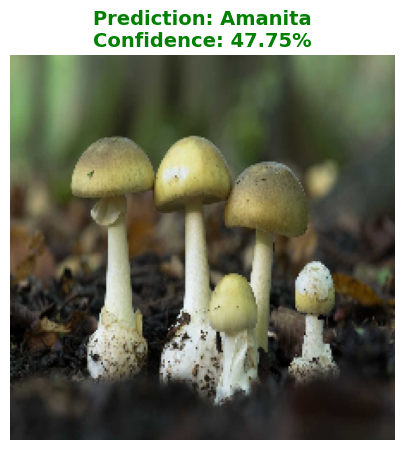

Top 3 Runner-up Guesses:
 - Amanita: 47.7%
 - Entoloma: 32.4%
 - Lactarius: 8.6%


In [ ]:
# ==============================================================================
# CELL 16: TEST THE SAVED MODEL WITH A NEW IMAGE (VISUALIZATION)
# ==============================================================================
from tensorflow.keras.preprocessing import image
final_pkl_path = "D:\\Machine-Learning-Models\\app\model\\image.pkl"
print("--- Loading Full Model Package from PKL ---")
with open(final_pkl_path, 'rb') as f:
    loaded_package = pickle.load(f)

# Reconstruct the TensorFlow Keras Model dynamically
test_model = tf.keras.models.model_from_json(loaded_package['architecture'])
test_model.set_weights(loaded_package['weights'])
saved_classes = loaded_package['classes']

print(f"Loaded {len(saved_classes)} classes successfully.")

print("\n🍄 --- PLEASE UPLOAD A MUSHROOM IMAGE TO TEST --- 🍄")
try:
    from google.colab import files
    uploaded_files = files.upload()

    for filename in uploaded_files.keys():
        print(f"\nProcessing {filename}...")

        # Load and resize the image to (224, 224)
        img = image.load_img(filename, target_size=(img_height, img_width))
        img_array = image.img_to_array(img)
        img_batch = tf.expand_dims(img_array, 0) # Create a pseudo-batch dimension

        # Make Prediction using our re-built model
        predictions = test_model.predict(img_batch)
        prediction_scores = predictions[0]

        # Determine the winner
        winning_index = np.argmax(prediction_scores)
        winning_class = saved_classes[winning_index]
        confidence_percentage = prediction_scores[winning_index] * 100

        # Visual Display
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Prediction: {winning_class}\nConfidence: {confidence_percentage:.2f}%",
                  fontsize=14, fontweight='bold', color='green')
        plt.show()

        print("Top 3 Runner-up Guesses:")
        top_3_indices = np.argsort(prediction_scores)[-3:][::-1]
        for i in top_3_indices:
            print(f" - {saved_classes[i]}: {prediction_scores[i]*100:.1f}%")
except ImportError:
    print("Skipping image upload - this feature requires execution inside Google Colab.")


ImportError: DLL load failed while importing _pywrap_tfe: The specified module could not be found.